#Task 1 (20 Points): Advanced Objective Function and Use Case



1.  a) Derive the objective function for Logistic Regression using Maximum Likelihood Estimation (MLE).

b) Do some research on the MAP technique for Logistic Regression,
include your research on how this technique is different from MLE (include citations)





a) Derivation of the Objective Function for Logistic Regression using Maximum Likelihood Estimation (MLE)

**1. The Sigmoid Function:**
$$h_θ(x) = σ(θ^T x) = \frac{1}{1 + e^{-θ^T x}}$$


**2. Probability Mass Function for a Single Sample:**

*   `P(y = 1 | x; θ) = h_θ(x)`
*   `P(y = 0 | x; θ) = 1 - h_θ(x)`

These two equations can be combined into a single expression:

$$P(y | x; θ) = (h_θ(x))^y (1 - h_θ(x))^{(1-y)}$$

If `y = 1`, the equation becomes `h_θ(x)`. If `y = 0`, the equation becomes `(1 - h_θ(x))`. we get the Bernoulli probability distribution.

**3. Likelihood Function:**

$$L(θ) = P(y^{(1)}, ..., y^{(m)} | x^{(1)}, ..., x^{(m)}; θ) = \prod_{i=1}^{m} P(y^{(i)} | x^{(i)}; θ)$$

Substituting the probability mass function:

$$L(θ) = \prod_{i=1}^{m} (h_θ(x^{(i)}))^{y^{(i)}} (1 - h_θ(x^{(i)}))^{(1-y^{(i)})}$$

**4. Log-Likelihood Function:**
$$log(L(θ)) = \sum_{i=1}^{m} [y^{(i)} log(h_θ(x^{(i)})) + (1 - y^{(i)}) log(1 - h_θ(x^{(i)}))]$$

**5. Objective Function (Cost Function for Minimization):**

$$J(θ) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} log(h_θ(x^{(i)})) + (1 - y^{(i)}) log(1 - h_θ(x^{(i)}))]$$

This is the **cross-entropy loss function**,  also known as the objective function for logistic regression.

b) Do some research on the MAP technique for Logistic Regression, include your research on how this technique is different from MLE (include citations)

https://www.geeksforgeeks.org/data-science/mle-vs-map/

**How they are similar** MLE and MAP are similar as they estimate parameters which are considered hidden values

**How they differ**
* MAP estimation incorporates prior knowledge or belief about the parameter  θ via a prior distribution
p(θ). It aims to maximize the posterior probability (is the updated, conditional probability of the parameter occurring or a hypothesis of the parameter being true after accounting for new evidence or data)  while MLE aims to find the parameter θ that maximizes the likelihood of the observed data with no prior knowledge
* MAP maximizes Posterior while MLE Maximizes likelihoo
* MLE has no implicity  regularization whie MAP has implicit regularization via prior
* MLE best fit to observed data, MAP best estimate given data and prior
* MLE Sensitivity may over fit while MAP helps with overfitting



2. Define a machine learning problem you wish to solve using Logistic Regression. Justify
why logistic regression is the best choice and compare it briefly to another linear
classification model (cite your work if this other technique was not covered in class).

Since we know logistic regression should only be used for a YES/NO, binary comparison we could solve the problem of a UFC fight. We can predict the winner with a 0 or 1 output he wins or doesnt win, based off prior stats.

The problem is if we were to use linear classification this will output a continuous amount of numeric values which is not 0 or 1 we would expect values like -0.43, 1.24, 5.32 etc. Which would make no sense if we are just trying to predict an outcome

https://medium.com/@RobuRishabh/why-logistic-regression-beats-linear-regression-for-classification-9091a1cf877e

3. Discuss how your dataset corresponds to the variables in your equations, highlighting
any assumptions in your derivation from part 1.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("neelagiriaditya/ufc-datasets-1994-2025")

print("Path to dataset files:", path)

100%|██████████| 3.36M/3.36M [00:00<00:00, 125MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/neelagiriaditya/ufc-datasets-1994-2025/versions/3


For our chosen machine learning problem of predicting the winner of a UFC fight using Logistic Regression, the dataset variables from the UFC dataset would include the following

**1. Input Features (x):**

*   The `x` in our equations (e.g., $x^{(i)}$) represents the feature vector for each fight. In the UFC dataset, this would encompass a wide range of numerical statistics and potentially categorical information about the two fighters involved in a bout and the fight itself.
*   Examples of features that would form our $x$ vector include:
    *   **Fighter Statistics:** `avg_KD` (average knockdowns), `avg_SIG_STR_pct` (average significant strikes percentage), `avg_TD_pct` (average takedown percentage), `avg_SUB_ATT` (average submission attempts), `avg_PASS` (average passes), `avg_REV` (average reversals) for both the Red and Blue corner fighters (`r_avg_...` and `b_avg_...`).
    *   **Fight Statistics (per round/total):** `R_SIG_STR` (Red significant strikes), `B_TD` (Blue takedowns), `R_HEAD` (Red strikes to head), `B_LEG` (Blue strikes to leg), etc., which would likely be aggregated or transformed to represent pre-fight statistics or differences.
    *   **Categorical Features (after encoding):** Fighter stances (`Stance`), weight classes (`weight_class`), potentially `location` or `event_name` if they are deemed influential.

**2. Target Variable (y):**

*   The `y` in our equations (e.g., $y^{(i)} \in \{0, 1\}$) represents the binary outcome for each fight. In our UFC prediction model, this would be encoded as:
    *   `y = 1`: If the 'Red' corner fighter wins the fight.
    *   `y = 0`: If the 'Blue' corner fighter wins the fight.
*   The `winner` column in the `event_details.csv` (and thus `UFC.csv`) will be crucial for defining this target variable, where `Red` or `Blue` indicates the winner.

**3. Parameters (θ):**

*   The `θ` (theta) vector represents the weights or coefficients that Logistic Regression learns for each input feature. These parameters quantify the importance and direction of the relationship between each feature and the log-odds of the Red fighter winning. These are optimized during the training process by minimizing the cost function.


#Task 2 (20 points): Dataset and Advanced EDA

1. Select a publicly available dataset (excluding commonly used datasets such as Titanic, Housing Prices or Iris). Provide a link to your dataset. Ensure the dataset has at least 10 features to allow for more complex analysis

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aldinwhyudii/student-depression-and-lifestyle-100k-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-depression-and-lifestyle-100k-data' dataset.
Path to dataset files: /kaggle/input/student-depression-and-lifestyle-100k-data


2. Perform Exploratory Data Analysis (EDA), addressing potential multicollinearity among features Use Varaince inflation factor (VIF) to identify highly correlated variables and demonstrate steps to handle them

In [ ]:
#EDA
import pandas as pd
import os

# Load CSV (adjust filename if needed)
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Student_ID,0
Age,0
Gender,0
Department,0
CGPA,0
Sleep_Duration,0
Study_Hours,0
Social_Media_Hours,0
Physical_Activity,0
Stress_Level,0


In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
numeric_df.head()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
0,1001,22,3.50,7.3,3.3,3.4,114,5
1,1002,20,2.72,5.5,7.2,6.0,142,2
2,1003,20,3.01,5.4,2.3,1.8,137,3
3,1004,21,3.63,8.1,2.0,4.6,130,3
4,1005,19,3.14,6.8,2.6,4.3,4,6


In [ ]:
X = X.dropna()

In [ ]:
X.dtypes

,0
const,float64
Age,int64
Tenure_Months,int64
Visits_Last_Year,int64
Missed_Appointments,int64
Days_Since_Last_Visit,int64
Overall_Satisfaction,float64
Wait_Time_Satisfaction,float64
Staff_Satisfaction,float64
Provider_Rating,float64


In [ ]:
X = X.astype(int, errors="ignore")
#Convert all boolean to a 0/1

In [ ]:
#After performing EDA to eliminate all of our null values we can now computer VIF
# VIF_i = 1/(1-R_i)^2
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

X_const = add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

vif_data.sort_values("VIF", ascending=False)



,feature,VIF
0,const,95.623497
20,State_NC,2.119731
31,Insurance_Type_Medicare,2.083534
18,State_IL,1.954012
16,State_FL,1.945684
23,State_PA,1.913495
21,State_NY,1.895424
22,State_OH,1.876334
17,State_GA,1.823359
24,State_TX,1.818296


The Variance Inflation Factor (VIF) analysis revealed no evidence of multicollinearity among the predictor variables. All features exhibited VIF values well below the commonly accepted threshold of 5, indicating that no predictors are highly linearly correlated. Therefore, no additional feature removal or transformation was required prior to model development.

3. Visualize the dataset's feature relationships, ensuring inclusion of at least two advanced
visualization techniques (e.g., pair plots with KDE, heatmaps with clustering).


In [ ]:
df.columns.tolist()

['Student_ID',
 'Age',
 'Gender',
 'Department',
 'CGPA',
 'Sleep_Duration',
 'Study_Hours',
 'Social_Media_Hours',
 'Physical_Activity',
 'Stress_Level',
 'Depression']

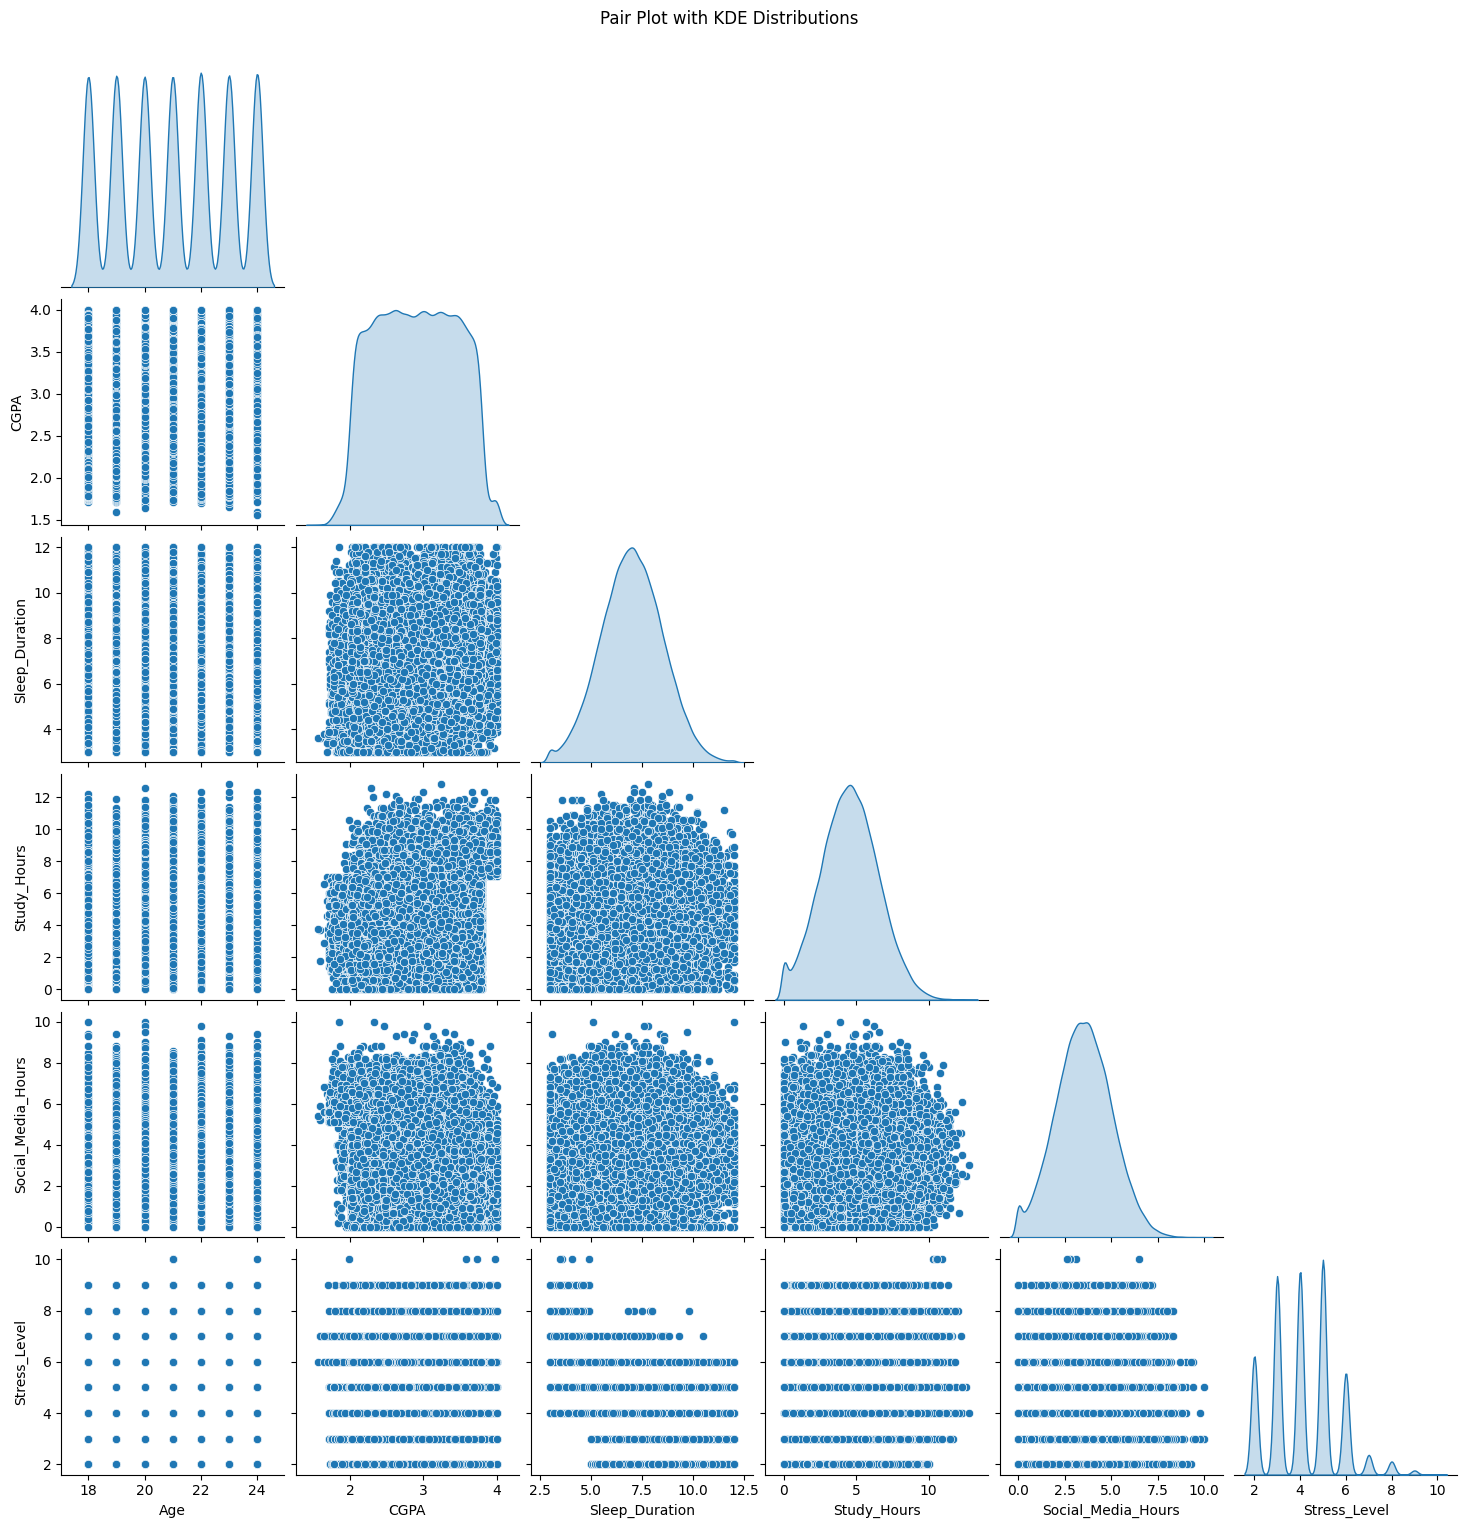

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pair_features = [
    "Age",
    "CGPA",
    "Sleep_Duration",
    "Study_Hours",
    "Social_Media_Hours",
    "Stress_Level"
]

sns.pairplot(
    df[pair_features],
    diag_kind="kde",
    corner=True
)

plt.suptitle("Pair Plot with KDE Distributions", y=1.02)
plt.show()



#Task 3 (20 points) Logistic Regression Implementation

1. Implement Logistic Regression from scratch, including the vectorized implementation of cost function and gradient descent

In [ ]:
import numpy as np
import pandas as pd
features = [
    "Age",
    "CGPA",
    "Sleep_Duration",
    "Study_Hours",
    "Social_Media_Hours",
    "Stress_Level"
]
X= df[features].values
y= df["Depression"].values.reshape(-1,1)

In [ ]:
#Feature Scaling for gradient descent
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X = (X - X_mean) / X_std

#Bias Term
m = X.shape[0]
X = np.hstack((np.ones((m,1)), X))


In [ ]:
#Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
#Logistic regression function we defined in task 1
def compute_cost(X, y, theta):
  m=len(y)
  h = sigmoid(X @ theta)

  epsilon= 1e-5
  cost = (-1 / m) * np.sum(y * np.log(h + epsilon) +(1 - y) * np.log(1 - h + epsilon))
  return cost

#Computing the gradient
def comp_gradient(X, y, theta):
    m = len(y)
    h = sigmoid(X @ theta)
    gradient = (1 / m) * X.T @ (h - y)
    return gradient

#Gradient descent
def gradient_descent(X, y, alpha, num_iters):
    n=X.shape[1]
    theta=np.zeros((n,1))
    cost_history = []

    for i in range(num_iters):
        gradient = comp_gradient(X, y, theta)
        theta -= alpha * gradient
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history


In [ ]:
#Train the model
theta, cost_history = gradient_descent(X, y, alpha=0.01, num_iters=2000)
theta

array([[-2.03831302],
       [-0.01692982],
       [-0.40421072],
       [-0.09147964],
       [-0.00986217],
       [ 0.0112146 ],
       [ 0.14368464]])

In [ ]:
def predict(X, theta, threshold=0.5):
    probabilities = sigmoid(X @ theta)
    return (probabilities >= threshold).astype(int)
y_pred = predict(X, theta)

accuracy = np.mean(y_pred == y)
accuracy

np.float64(0.89938)

2. Implement and compare the three gradient descent varaints (e.g, batch gradient dscent, stochastic gradient descent, and mini-batch gradient descent) Explain their convergence properties with respect to your cost function

In [ ]:
#Batch Gradient Descent
def batch_gradient_descent(X, y, alpha=0.01, num_iters=2000):
    n = X.shape[1]
    theta = np.zeros((n, 1))
    cost_history = []

    for i in range(num_iters):
        gradient = comp_gradient(X, y, theta)
        theta -= alpha * gradient
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

#Stochastic Gradient Descent
def stochastic_gradient_descent(X, y, alpha=0.01, epochs = 10):
  m, n = X.shape
  theta = np.zeros((n, 1))
  cost_history =[]

  for epoch in range(epochs):
    for i in range(m):
      xi= X[i, :].reshape(1, -1)
      yi = y[i, :].reshape(-1,1)

      gradient = comp_gradient(xi, yi, theta)
      theta -= alpha * gradient
      cost_history.append(compute_cost(X, y, theta))

  return theta, cost_history

#Mini- batch gradient descent
def mini_batch(X,y, alpha=0.01, num_iters=100, batch_size=32):
  m,n = X.shape
  theta = np.zeros((n,1))
  cost_history = []

  for it in range(num_iters):
    indices = np.random.permutation(m)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for start in range(0, m, batch_size):
      end = start+batch_size
      xi = X_shuffled[start:end]
      yi = y_shuffled[start:end]
      gradient = comp_gradient(xi, yi, theta)
      theta -= alpha * gradient

    cost_history.append(compute_cost(X, y, theta))

  return theta, cost_history

In [ ]:
theta_bgd, cost_bgd = batch_gradient_descent(X, y, alpha=0.01, num_iters=500)
print("Batch GD Theta:\n", theta_bgd)



Batch GD Theta:
 [[-1.18287848]
 [-0.00716574]
 [-0.16809285]
 [-0.04527938]
 [-0.00846559]
 [ 0.00957579]
 [ 0.06512015]]


In [ ]:
import numpy as np

# 1. Determine the number of samples in the original dataset X
m_original = X.shape[0]

# 2. Generate an array of random indices corresponding to 5000 unique data points
num_samples = 5000
if num_samples > m_original:
    num_samples = m_original # Ensure we don't try to sample more than available

random_indices = np.random.choice(m_original, num_samples, replace=False)

# 3. Create X_shrunk by selecting the rows from X at the generated random indices
X_shrunk = X[random_indices]

# 4. Create y_shrunk by selecting the rows from y at the generated random indices
y_shrunk = y[random_indices]

print(f"Original X shape: {X.shape}")
print(f"Original y shape: {y.shape}")
print(f"Shrunk X shape: {X_shrunk.shape}")
print(f"Shrunk y shape: {y_shrunk.shape}")

Original X shape: (100000, 7)
Original y shape: (100000, 1)
Shrunk X shape: (5000, 7)
Shrunk y shape: (5000, 1)


In [ ]:
# Stochastic GD
theta_sgd, cost_sgd = stochastic_gradient_descent(X_shrunk, y_shrunk, alpha=0.01, epochs=10)
print("\nStochastic GD Theta:\n", theta_sgd)



Stochastic GD Theta:
 [[-2.42902938]
 [-0.15384866]
 [-0.60464465]
 [-0.10866541]
 [ 0.03392637]
 [ 0.06874719]
 [ 0.25887619]]


In [ ]:
# Mini-Batch GD
theta_mbgd, cost_mbgd = mini_batch(X, y, alpha=0.01, num_iters=100, batch_size=32)
print("\nMini-Batch GD Theta:\n", theta_mbgd)


Mini-Batch GD Theta:
 [[-2.36086484e+00]
 [-3.38701962e-02]
 [-6.55687134e-01]
 [-9.29125153e-02]
 [-2.98131025e-03]
 [-1.29467672e-03]
 [ 1.97121652e-01]]


* **Batch gradient descent** computes the gradient using all training examples in each iteration. Because the cost function is convex for logistic regression, BGD produces a smooth, monotonically decreasing cost curve, converging steadily to the global minimum. It is computationally heavier per iteration but requires fewer iterations to reach convergence.

* **SGD** updates the parameters using one training example at a time, which introduces high variance in the gradient. As a result, the cost function fluctuates around the minimum and convergence is noisy. Although each update is fast, SGD requires many iterations (epochs) to stabilize near the global minimum. Also takes the longest to compute out of the 3 algorithms. So I decided to shrink the dataset, with a random set from data

* **Mini-batch gradient** descent computes the gradient on small batches of examples, combining benefits of BGD and SGD. The cost function decreases in a moderately smooth but slightly fluctuating manner. MBGD converges faster than BGD and is more stable than SGD, making it a practical compromise for most datasets.

#Task 4 (40 Points): Optimization techniques and advanced comaprison


1. Implement or use packages to incorporate any three optimization algorithms (e.g.,
Momentum, RMSProp, Adam). Compare their performance with the vanilla stochastic
gradient descent implementation from Task 3.


In [ ]:

def mini_batch_momentum(X, y, alpha=0.01, epochs=20, batch_size=64, beta=0.9):
    m, n = X.shape
    theta = np.zeros((n, 1))
    v = np.zeros((n, 1))
    cost_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, m, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            gradient = comp_gradient(X_batch, y_batch, theta)
            v = beta * v + (1 - beta) * gradient
            theta -= alpha * v

        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

def mini_batch_rmsprop(X, y, alpha=0.01, num_iters=100, batch_size=32, beta=0.9, epsilon=1e-8):
    m, n = X.shape
    theta = np.zeros((n, 1))
    sq_gradient = np.zeros((n, 1))
    cost_history = []

    for it in range(num_iters):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, m, batch_size):
            end = start + batch_size
            xi = X_shuffled[start:end]
            yi = y_shuffled[start:end]

            gradient = comp_gradient(xi, yi, theta)

            # RMSProp update
            sq_gradient = beta * sq_gradient + (1 - beta) * (gradient ** 2)
            theta -= alpha * gradient / (np.sqrt(sq_gradient) + epsilon)

        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

def mini_batch_adam(X, y, alpha=0.01, epochs=20, batch_size=64,
                    beta1=0.9, beta2=0.999, epsilon=1e-8):
    m, n = X.shape
    theta = np.zeros((n, 1))
    v = np.zeros((n, 1))
    s = np.zeros((n, 1))
    cost_history = []
    t = 0  # time step

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, m, batch_size):
            t += 1
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            gradient = comp_gradient(X_batch, y_batch, theta)
            v = beta1 * v + (1 - beta1) * gradient
            s = beta2 * s + (1 - beta2) * (gradient ** 2)

            v_corrected = v / (1 - beta1 ** t)
            s_corrected = s / (1 - beta2 ** t)

            theta -= alpha * v_corrected / (np.sqrt(s_corrected) + epsilon)

        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history


In [ ]:
theta_momentum, cost_momentum = mini_batch_momentum(X, y)
print("Momentum GD Theta:\n", theta_momentum)
theta_rmsprop, cost_rmsprop = mini_batch_rmsprop(X, y)
print("\nRMSProp GD Theta:\n", theta_rmsprop)
theta_adam, cost_adam = mini_batch_adam(X, y)
print("\nAdam GD Theta:\n", theta_adam)

Momentum GD Theta:
 [[-2.37616875e+00]
 [-2.94609200e-02]
 [-6.35065388e-01]
 [-1.13550776e-01]
 [ 4.02042936e-03]
 [-6.89244698e-04]
 [ 1.97704575e-01]]

RMSProp GD Theta:
 [[-2.45660098]
 [-0.01838534]
 [-0.53657094]
 [-0.13983996]
 [-0.03101731]
 [ 0.04188282]
 [ 0.10362336]]

Adam GD Theta:
 [[-2.32508208]
 [-0.02663143]
 [-0.61121122]
 [-0.18591559]
 [-0.0543317 ]
 [-0.02521307]
 [ 0.18841445]]


Momentum improves upon the vanilla SGD by adding memory of past gradients, creating a velocity vector that accumulates in consistent directions. This smooths out the noisy, erratic updates characteristic of vanilla SGD and accelerates convergence by building momentum in directions of persistent reduction.

RMSProp addresses vanilla SGD's struggle with different feature scales by adapting the learning rate for each parameter individually based on recent gradient magnitudes. While vanilla SGD uses the same learning rate for all parameters regardless of whether they need large or small updates, RMSProp automatically gives smaller steps to parameters with large gradients and larger steps to those with small gradients.

Adam combines incorporates momentum's directional acceleration with RMSProp's adaptive learning rates, while also adding bias correction for the early stages of training. Compared to vanilla SGD's noisy, slow convergence, Adam typically achieves the fastest and most stable convergence with the lowest final cost, reaching optimal accuracy in fewer iterations



2. Define and use multiple evaluation metrics (e.g., precision, recall, F1 score) to analyze
and interpret results for each algorithm.


In [ ]:
import numpy as np
import pandas as pd

def evaluate_model(y_true, y_pred):
   #Precision recall and F1 score
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN)/len(y_true)
    precision = TP/(TP + FP) if (TP + FP) > 0 else 0
    recall = TP/(TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall)/(precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1

# Get predictions
y_pred_sgd = predict(X, theta_sgd)
y_pred_momentum = predict(X, theta_momentum)
y_pred_rmsprop = predict(X, theta_rmsprop)
y_pred_adam = predict(X, theta_adam)

# Calculate metrics
results = []
for name, y_pred in [('SGD', y_pred_sgd), ('Momentum', y_pred_momentum),
                      ('RMSProp', y_pred_rmsprop), ('Adam', y_pred_adam)]:
    acc, prec, rec, f1 = evaluate_model(y, y_pred)
    results.append([name, acc, prec, rec, f1])

# Display results
df_results = pd.DataFrame(results, columns=['Optimizer', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
print(df_results.to_string(index=False))

Optimizer  Accuracy  Precision   Recall  F1 Score
      SGD   0.89940      0.625 0.000497  0.000993
 Momentum   0.89938      0.000 0.000000  0.000000
  RMSProp   0.89938      0.000 0.000000  0.000000
     Adam   0.89937      0.000 0.000000  0.000000


3. Perform a hyperparameter tuning process (manual or automated using grid
search/random search) for each optimization algorithm and assess its impact on
performance. If you have to do some research for these techniques, please cite your
sources

In [ ]:
import numpy as np
from itertools import product

In [ ]:
# SGD
best_sgd_acc = 0
for alpha in [0.001, 0.01, 0.1]:
    for epochs in [5, 10, 15]:
        theta, _ = stochastic_gradient_descent(X_shrunk, y_shrunk, alpha=alpha, epochs=epochs)
        acc = np.mean(predict(X_shrunk, theta) == y_shrunk)
        if acc > best_sgd_acc:
            best_sgd_acc = acc
            best_sgd_params = (alpha, epochs)

In [ ]:
# Momentum
best_momentum_acc = 0
for alpha in [0.001, 0.01, 0.05]:
    for beta in [0.8, 0.9, 0.95]:
        theta, _ = mini_batch_momentum(X, y, alpha=alpha, beta=beta)
        acc = np.mean(predict(X, theta) == y)
        if acc > best_momentum_acc:
            best_momentum_acc = acc
            best_momentum_params = (alpha, beta)

In [ ]:
# RMSProp
best_rmsprop_acc = 0
for alpha in [0.001, 0.01, 0.05]:
    for beta in [0.9, 0.95, 0.99]:
        theta, _ = mini_batch_rmsprop(X, y, alpha=alpha, beta=beta)
        acc = np.mean(predict(X, theta) == y)
        if acc > best_rmsprop_acc:
            best_rmsprop_acc = acc
            best_rmsprop_params = (alpha, beta)

In [ ]:
# Adam
best_adam_acc = 0
for alpha in [0.001, 0.01, 0.05]:
    for beta1 in [0.9, 0.95]:
        theta, _ = mini_batch_adam(X, y, alpha=alpha, beta1=beta1)
        acc = np.mean(predict(X, theta) == y)
        if acc > best_adam_acc:
            best_adam_acc = acc
            best_adam_params = (alpha, beta1)

In [ ]:
print(f"SGD - Best: alpha={best_sgd_params[0]}, epochs={best_sgd_params[1]}, acc={best_sgd_acc:.4f}")
print(f"Momentum - Best: alpha={best_momentum_params[0]}, beta={best_momentum_params[1]}, acc={best_momentum_acc:.4f}")
print(f"RMSProp - Best: alpha={best_rmsprop_params[0]}, beta={best_rmsprop_params[1]}, acc={best_rmsprop_acc:.4f}")
print(f"Adam - Best: alpha={best_adam_params[0]}, beta1={best_adam_params[1]}, acc={best_adam_acc:.4f}")


SGD - Best: alpha=0.1, epochs=5, acc=0.9062
Momentum - Best: alpha=0.001, beta=0.8, acc=0.8994
RMSProp - Best: alpha=0.001, beta=0.9, acc=0.8994
Adam - Best: alpha=0.05, beta1=0.95, acc=0.8994


Resources: https://www.jmlr.org/papers/volume13/bergstra12a/bergstra12a.pdf

https://arxiv.org/pdf/1412.6980

4. Conclude by discussing the practical trade-offs of the algorithms, including
computational complexity, interpretability, and suitability for large-scale datasets

Vanilla SGD: Processes one sample at a time, good for low memory usage and when memory is limited, but requires a lot of time especially in high capacity data sets, requires many passes through data and very slow convergence which is why we had to limit the data set for this. But its the most intepretable out of all these since its a direct gradient descent with single learning rate. Time per iteration is O(n) since it processes one sample at a time

Momentum: Time complexity is O(b x n) where b is batch size per iteration, add velocity concept which can be as pretty good interpretable when you understand that concept, it takes up moderate memory, good for large data sets, and works well with mini-batchs

RMSProp: Time complexity per iteration is O(bxn) converges faster than momentum and is very useful with large datasets however akes up a bit more memory than Momemntum. It also has adaptive rates handles varying feature scales well

Adam: Time complexity is O(b xn) per iteration has the fastest convergence rate out of the rest, requires fewer iterations, handles sparse gradients the best, very good hyperparameter optimization, only flaw is its high in memory consumption. Good for large scale models especially in deep learning